# Diffusion Sampling

Sampling loops built on top of the pretrained DeepFloyd IF denoisers: the forward
process, one-step and iterative denoising, classifier-free guidance, image-to-image
translation, inpainting, visual anagrams and hybrid images.


# Part 0: Setup
### Using DeepFloyd

In [1]:
import os
from huggingface_hub import login

# Read the token from the environment rather than hard-coding it.
login(token=os.environ["HF_TOKEN"])


### Install Dependencies

In [2]:
! pip install -q \
  diffusers \
  transformers \
  safetensors \
  sentencepiece \
  accelerate \
  bitsandbytes \
  einops \
  mediapy \
  accelerate

### Import Dependencies

In [4]:
from PIL import Image
import mediapy as media
from pprint import pprint
from tqdm import tqdm

import torch
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from diffusers import DiffusionPipeline
from transformers import T5EncoderModel
import matplotlib.pyplot as plt
import numpy as np


# For downloading web images
import requests
from io import BytesIO

device = 'mps'

'NoneType' object has no attribute 'cadam32bit_grad_fp32'


### Loading the models

In [5]:
# Load DeepFloyd IF stage I
stage_1 = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=None,
    variant="fp16",
    torch_dtype=torch.float16,
)
stage_1.to(device)

# Load DeepFloyd IF stage II
stage_2 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-II-L-v1.0",
                text_encoder=None,
                variant="fp16",
                torch_dtype=torch.float16,
              )
stage_2.to(device)

Couldn't connect to the Hub: (MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/models/DeepFloyd/IF-I-L-v1.0 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x174a49640>: Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: c1290915-6268-4ea0-aed6-ea31510362c4)').
Will try to load from local cache.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 10.19it/s]
Couldn't connect to the Hub: (MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/models/DeepFloyd/IF-II-L-v1.0 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x174f1a600>: Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 8f83bf2e-97da-4f47-ad6c-2e3c4ac72d4e)').
Will try to load from local cache.
Loading pipeline componen

IFSuperResolutionPipeline {
  "_class_name": "IFSuperResolutionPipeline",
  "_diffusers_version": "0.31.0",
  "_name_or_path": "DeepFloyd/IF-II-L-v1.0",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_noising_scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "deepfloyd_if",
    "IFSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "text_encoder": [
    null,
    null
  ],
  "tokenizer": [
    "transformers",
    "T5Tokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "watermarker": [
    "deepfloyd_if",
    "IFWatermarker"
  ]
}

### Disclaimer about Text Embeddings

### Downloading Precomputed Text Embeddings

In [6]:

prompt_embeds_dict = torch.load('prompt_embeds_dict.pth', map_location=torch.device('mps'))

pprint(list(prompt_embeds_dict.keys()))

['an oil painting of a snowy mountain village',
 'a photo of the amalfi cost',
 'a photo of a man',
 'a photo of a hipster barista',
 'a photo of a dog',
 'an oil painting of people around a campfire',
 'an oil painting of an old man',
 'a lithograph of waterfalls',
 'a lithograph of a skull',
 'a man wearing a hat',
 'a high quality photo',
 '',
 'a rocket ship',
 'a pencil']


/var/folders/m1/63ns6dts5dlf4t76wyvsczgm0000gn/T/ipykernel_93179/2659218284.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  prompt_embeds_dict = torch.load('prompt_embed

### Seed your Work

In [7]:
def seed_everything(seed):
  torch.mps.manual_seed(seed)

YOUR_SEED = 180
seed_everything(YOUR_SEED)

### Sampling from the Model

In [8]:
# NOTE: My mac does not have enough ram to run this part, this part was run in google colab!!!

# # Get prompt embeddings from the precomputed cache.
# # `prompt_embeds` is of shape [N, 77, 4096]
# # 77 comes from the max sequence length that deepfloyd will take
# # and 4096 comes from the embedding dimension of the text encoder
# # `negative_prompt_embeds` is the same shape as `prompt_embeds` and is used
# # for Classifier Free Guidance. You can find out more from:
# #   - https://arxiv.org/abs/2207.12598
# #   - https://sander.ai/2022/05/26/guidance.html
# prompts = [
#     'an oil painting of a snowy mountain village',
#     'a man wearing a hat',
#     "a rocket ship",
# ]
# prompt_embeds = torch.cat([
#     prompt_embeds_dict[prompt] for prompt in prompts
# ], dim=0)
# negative_prompt_embeds = torch.cat(
#     [prompt_embeds_dict['']] * len(prompts)
# )

# # Sample from stage 1
# # Outputs a [N, 3, 64, 64] torch tensor
# # num_inference_steps is an integer between 1 and 1000, indicating how many
# # denoising steps to take: lower is faster, at the cost of reduced quality
# stage_1_output = stage_1(
#     prompt_embeds=prompt_embeds,
#     negative_prompt_embeds=negative_prompt_embeds,
#     num_inference_steps=10,
#     output_type="pt"
# ).images

# # Sample from stage 2
# # Outputs a [N, 3, 256, 256] torch tensor
# # num_inference_steps is an integer between 1 and 1000, indicating how many
# # denoising steps to take: lower is faster, at the cost of reduced quality
# stage_2_output = stage_2(
#     image=stage_1_output,
#     num_inference_steps=10,
#     prompt_embeds=prompt_embeds,
#     negative_prompt_embeds=negative_prompt_embeds,
#     output_type="pt",
# ).images

# # Display images
# # We need to permute the dimensions because `media.show_images` expects
# # a tensor of shape [N, H, W, C], but the above stages gives us tensors of
# # shape [N, C, H, W]. We also need to normalize from [-1, 1], which is the
# # output of the above stages, to [0, 1]
# media.show_images(
#     stage_1_output.permute(0, 2, 3, 1).cpu() / 2. + 0.5,
#     titles=prompts)
# media.show_images(
#     stage_2_output.permute(0, 2, 3, 1).cpu() / 2. + 0.5,
#     titles=prompts)

# Part 1: Sampling Loops

Test image:


""

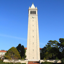

In [9]:
# Get scheduler parameters
alphas_cumprod = stage_1.scheduler.alphas_cumprod

# Get test image
test_im = Image.open('campanile.jpg')

# For stage 1: Resize to (64, 64), convert to tensor, rescale to [-1, 1], and
# add a batch dimension. The result is a (1, 3, 64, 64) tensor
test_im = Image.open('campanile.jpg').resize((64, 64))
test_im = TF.to_tensor(test_im)
test_im = 2 * test_im - 1
test_im = test_im[None]

# Show test image
print('Test image:')
media.show_image(test_im[0].permute(1,2,0) / 2. + 0.5)

# 1.1 Implementing the forward process

Noisy Campanile at t=0

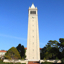

Noisy Campanile at t=250

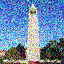

Noisy Campanile at t=500

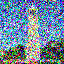

Noisy Campanile at t=750

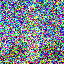

In [10]:
def forward(im, t):
  # Here we take the mentioned image of shape torch.Size([1, 3, 64, 64])
  # and then use the timestep t to apply the noise
  # a_bar is noise coefficient, amount of noise added, which has been set by the ppl training the model
  # randn_like is N(0,1)
  a_bar = alphas_cumprod[t]
  eps = torch.randn_like(im)
  return (a_bar**0.5) * im + (1 - a_bar)**0.5 * eps

for i in [0, 250, 500, 750]:
  im_noisy = forward(test_im, i)
  title = 'Noisy Campanile at t=' + str(i)
  media.show_image(im_noisy[0].permute(1,2,0) / 2. + 0.5, title=title)

# 1.2 Classical Denoising

Noisy_Campanile_t_250

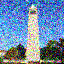

Gaussian_Denoise_Campanile_t_250

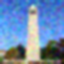

Noisy_Campanile_t_500

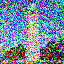

Gaussian_Denoise_Campanile_t_500

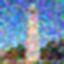

Noisy_Campanile_t_750

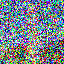

Gaussian_Denoise_Campanile_t_750

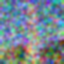

In [11]:
media.set_show_save_dir('output')
for i in [250, 500, 750]:
    im_noisy = forward(test_im, i)
    title = 'Noisy_Campanile_t_' + str(i)
    media.show_image(im_noisy[0].permute(1,2,0) / 2. + 0.5, title=title)
    title = 'Gaussian_Denoise_Campanile_t_' + str(i)
    im_denoise = TF.gaussian_blur(im_noisy, kernel_size=7)
    media.show_image(im_denoise[0].permute(1,2,0) / 2. + 0.5, title=title)

# 1.3 Implementing One Step Denoising

1_3_original

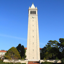

1_3_noise_unet_t_250

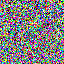

1_3_denoise_unet_t_250

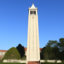

1_3_noise_unet_t_500

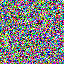

1_3_denoise_unet_t_500

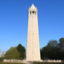

1_3_noise_unet_t_750

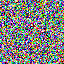

1_3_denoise_unet_t_750

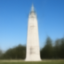

In [12]:
prompt_embeds = prompt_embeds_dict["a high quality photo"]
title = '1_3_original'
media.show_image(test_im[0].permute(1,2,0) / 2. + 0.5, title=title)
with torch.no_grad():
  for t in [250, 500, 750]:
    # Get alpha bar
    alpha_cumprod = alphas_cumprod[t]

    # Run forward process
    eps = torch.randn_like(test_im)
    im_noisy = (alpha_cumprod**0.5) * test_im + (1 - alpha_cumprod)**0.5 * eps

    # Estimate noise in noisy image
    noise_est = stage_1.unet(
        im_noisy.half().to(torch.device(device)),
        t,
        encoder_hidden_states=prompt_embeds,
        return_dict=False
    )[0]

    # Take only first 3 channels, and move result to cpu
    noise_est = noise_est[:, :3].cpu()
    title = '1_3_noise_unet_t_' + str(t)
    media.show_image(noise_est[0].permute(1,2,0) / 2. + 0.5, title=title)
    # Remove the noise
    clean_est = (im_noisy - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
    title = '1_3_denoise_unet_t_' + str(t)
    media.show_image(clean_est[0].permute(1,2,0) / 2. + 0.5, title=title)


# 1.4 Implementing Iterative Denoising

In [13]:
# Make timesteps. Must be list of ints satisfying:
# - monotonically decreasing
# - ends at 0
# - begins close to or at 999

# Make strided_timesteps

strided_timesteps = list(range(990, -1, -30))

stage_1.scheduler.set_timesteps(timesteps=strided_timesteps)    # Need this b/c variance computation

In [14]:
def add_variance(predicted_variance, t, image):
  '''
  Args:
    predicted_variance : (1, 3, 64, 64) tensor, last three channels of the UNet output
    t: scale tensor indicating timestep
    image : (1, 3, 64, 64) tensor, noisy image

  Returns:
    (1, 3, 64, 64) tensor, image with the correct amount of variance added
  '''
  # Add learned variance
  variance = stage_1.scheduler._get_variance(t, predicted_variance=predicted_variance)
  variance_noise = torch.randn_like(image)
  variance = torch.exp(0.5 * variance) * variance_noise
  return image + variance

1_4_Noisy_Campanile_t_690

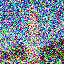

1_4_Noisy_Campanile_t_540

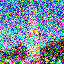

1_4_Noisy_Campanile_t_390

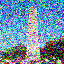

1_4_Noisy_Campanile_t_240

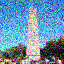

1_4_Noisy_Campanile_t_90

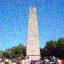

1_4_original

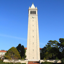

1_4_Iterative_Denoised_Campanile_t_690

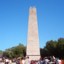

1_4_One_Step_Denoised_Campanile

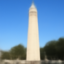

1_4_Gaussian_Blurred_Campanile

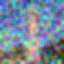

In [15]:
def iterative_denoise(image, i_start, prompt_embeds, timesteps, display=False):
  with torch.no_grad():
    loop_number = 0
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1] # t', so less noisy

      # Get alphas, betas
      alpha_cumprod = alphas_cumprod[t]
      alpha_cumprod_prev = alphas_cumprod[prev_t]
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # Get noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)

      # Eq (6) and (7) of DDPM
      clean_est = (image - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
      pred_prev_image = (alpha_cumprod_prev**0.5 * beta * clean_est)/(1 - alpha_cumprod) + (alpha ** 0.5 * (1 - alpha_cumprod_prev) * image)/(1 - alpha_cumprod) 
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)
      loop_number += 1
      if loop_number % 5 == 1 and display:
        title = '1_4_Noisy_Campanile_t_' + str(t)
        media.show_image(pred_prev_image.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

prompt_embeds = prompt_embeds_dict["a high quality photo"]

# Add noise
i_start = 10
t = strided_timesteps[i_start]
im_noisy = forward(test_im, t).half().to(torch.device(device))

# Denoise
clean = iterative_denoise(im_noisy,
                          i_start=i_start,
                          prompt_embeds=prompt_embeds,
                          timesteps=strided_timesteps,
                          display=True)

# One step denoise
title = '1_4_original'
media.show_image(np.transpose(test_im[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_4_Iterative_Denoised_Campanile_t_' + str(t)
media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)

noise_est = stage_1.unet(
    im_noisy.half().to(torch.device(device)),
    t,
    encoder_hidden_states=prompt_embeds,
    return_dict=False
)[0]
noise_est = noise_est[:, :3]
clean_one_step = (im_noisy - (1 - alphas_cumprod[t])**0.5 * noise_est) / (alphas_cumprod[t]**0.5)
title = '1_4_One_Step_Denoised_Campanile'
media.show_image(clean_one_step.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

# Gaussian blur denoise

blur_filtered = TF.gaussian_blur(im_noisy, kernel_size=5, sigma=2)
title = '1_4_Gaussian_Blurred_Campanile'
media.show_image(blur_filtered.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

# 1.5 Diffusion Model Sampling

1_5_sample_1

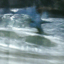

1_5_sample_2

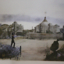

1_5_sample_3

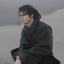

1_5_sample_4

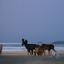

1_5_sample_5

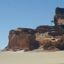

In [16]:
# Please use this text prompt
prompt_embeds = prompt_embeds_dict["a high quality photo"]

generated = {}

for i in range(5):
    random_noise = torch.randn_like(test_im).half().to(torch.device(device))
    clean = iterative_denoise(random_noise,
                          i_start=0,
                          prompt_embeds=prompt_embeds,
                          timesteps=strided_timesteps)
    title = '1_5_sample_' + str(i + 1)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
    generated[i] = clean
    


# 1.6 Classifier Free Guidance

1_6_sample_1

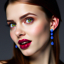

1_6_sample_2

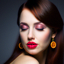

1_6_sample_3

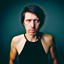

1_6_sample_4

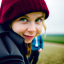

1_6_sample_5

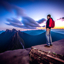

In [17]:
# The condition prompt embedding
prompt_embeds = prompt_embeds_dict['a high quality photo']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']

def iterative_denoise_cfg(image, i_start, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=False):
  with torch.no_grad():
    loop_number = 0
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # Get alphas, betas

      alpha_cumprod = alphas_cumprod[t]
      alpha_cumprod_prev = alphas_cumprod[prev_t]
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # Get cond noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)

      # Do classifier free guidance

      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)

      # Eq (6) and (7) of DDPM

      clean_est = (image - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
      pred_prev_image = (alpha_cumprod_prev**0.5 * beta * clean_est)/(1 - alpha_cumprod) + (alpha ** 0.5 * (1 - alpha_cumprod_prev) * image)/(1 - alpha_cumprod) 
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)
      loop_number += 1
      if loop_number % 5 == 1 and display:
        title = '1_5_Noisy_Campanile_t_' + str(t)
        media.show_image(pred_prev_image.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

generated = {}

for i in range(5):
    random_noise = torch.randn_like(test_im).half().to(torch.device(device))
    clean = iterative_denoise_cfg(random_noise,
                          i_start=0,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps)
    title = '1_6_sample_' + str(i + 1)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
    generated[i] = clean

# 1.7 Image-to-image Translation

1_7_img1_istart_1

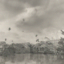

1_7_img1_istart_3

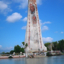

1_7_img1_istart_5

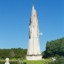

1_7_img1_istart_7

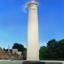

1_7_img1_istart_10

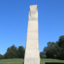

1_7_img1_istart_20

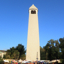

In [19]:
# Image 1
prompt_embeds = prompt_embeds_dict["a high quality photo"]
imgs_dict = {}
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=0)
    title = '1_7_img1_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)

1_7_img2_istart_1

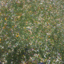

1_7_img2_istart_3

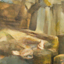

1_7_img2_istart_5

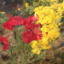

1_7_img2_istart_7

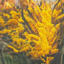

1_7_img2_istart_10

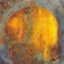

1_7_img2_istart_20

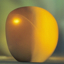

1_7_img2_istart_original

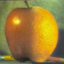

In [ ]:
# Image 2
test_im2 = Image.open('data/oranapple.png').resize((64, 64))
test_im2 = TF.to_tensor(test_im2)
test_im2 = 2 * test_im2 - 1
test_im2 = test_im2[None]
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im2, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=0)
    title = '1_7_img2_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_img2_istart_original'
media.show_image(test_im2[0].permute(1,2,0) / 2. + 0.5, title=title)

1_7_img3_istart_1

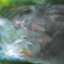

1_7_img3_istart_3

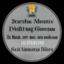

1_7_img3_istart_5

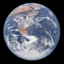

1_7_img3_istart_7

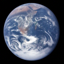

1_7_img3_istart_10

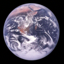

1_7_img3_istart_20

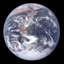

1_7_img3_istart_original

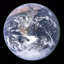

In [ ]:
# Image 3
test_im3 = Image.open('data/earth.jpg').resize((64, 64))
test_im3 = TF.to_tensor(test_im3)
test_im3 = 2 * test_im3 - 1
test_im3 = test_im3[None]
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im3, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=0)
    title = '1_7_img3_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_img3_istart_original'
media.show_image(test_im3[0].permute(1,2,0) / 2. + 0.5, title=title)

## 1.7.1 Editing Hand-Drawn and Web Images

In [ ]:
# @title Function to Process Images

def process_pil_im(img):
  '''
  Transform a PIL image
  '''

  # Convert to RGB
  img = img.convert('RGB')

  # Define the transform to resize, convert to tensor, and normalize to [-1, 1]
  transform = transforms.Compose([
      transforms.Resize(64),               # Resize shortest side to 64
      transforms.CenterCrop(64),             # Center crop
      transforms.ToTensor(),               # Convert image to PyTorch tensor with range [0, 1]
      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to range [-1, 1]
  ])

  # Apply the transformations and add batch dim
  img = transform(img)[None]

  # Show image
  print("Processed image")
  media.show_image(img[0].permute(1,2,0) / 2 + 0.5)

  return img

Processed image


""

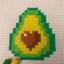

1_7_1_internet_original

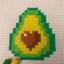

In [ ]:
# @title Download Images from Web

################
## CHANGE URL ##
################
url = "https://pbs.twimg.com/profile_images/969338395070730246/Y91ernB4_400x400.jpg"
# url = "https://i.pinimg.com/originals/76/e5/d5/76e5d55d0c8c6ec65135b42a2c5cbd98.jpg"
################
################

# Download image from URL and process
response = requests.get(url)
web_im = Image.open(BytesIO(response.content))
web_im = process_pil_im(web_im)
title = '1_7_1_internet_original'
media.show_image(web_im[0].permute(1,2,0) / 2. + 0.5, title=title)

  0%|          | 0/6 [00:00<?, ?it/s]

1_7_1_img1_istart_1

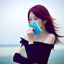

 17%|█▋        | 1/6 [00:18<01:31, 18.36s/it]

1_7_1_img1_istart_3

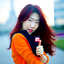

 33%|███▎      | 2/6 [00:36<01:12, 18.12s/it]

1_7_1_img1_istart_5

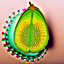

 50%|█████     | 3/6 [00:52<00:51, 17.14s/it]

1_7_1_img1_istart_7

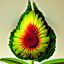

 67%|██████▋   | 4/6 [01:07<00:32, 16.23s/it]

1_7_1_img1_istart_10

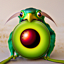

 83%|████████▎ | 5/6 [01:20<00:15, 15.19s/it]

1_7_1_img1_istart_20

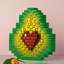

100%|██████████| 6/6 [01:27<00:00, 14.63s/it]


1,3,5,7,10,20

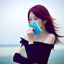
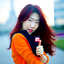
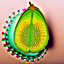
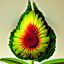
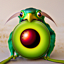
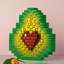

In [ ]:
prompt_embeds = prompt_embeds_dict["a high quality photo"]

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
  # Add noise
  t = strided_timesteps[i_start]
  im_noisy = forward(web_im, t).half().to(device)

  # Denoise
  clean = iterative_denoise_cfg(im_noisy,
                                i_start=i_start,
                                prompt_embeds=prompt_embeds,
                                uncond_prompt_embeds=uncond_prompt_embeds,
                                timesteps=strided_timesteps,
                                display=False)

  # Add to dict to display later
  imgs_dict[i_start] = clean[0].transpose(1,2,0) / 2. + 0.5
  title = '1_7_1_img1_istart_' + str(i_start)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)

media.show_images(imgs_dict)

In [20]:
# This funciton was ran on google collab and I have commented it out here and imported the results

# # @title Hand Drawn Images

# ############
# ### N.B. ###
# ############

# # This code is from: https://gist.github.com/karim23657/5ad5e067c1684dbc76c93bd88bf6fa53
# # The board is hardcoded to be size 300 x 600, but we're using square images
# # so please just draw in the center of the board
# # In addition, this gist may be taken down or change location,
# # which will break things in the future

# ############
# ############

# from base64 import b64decode
# from IPython.display import HTML
# from google.colab.output import eval_js
# import urllib.request
# board_html = urllib.request.urlopen('https://gist.githubusercontent.com/karim23657/5ad5e067c1684dbc76c93bd88bf6fa53/raw/2ef57f881bc700c2c346bd6c7a7f2d5364b21048/drawing%2520board.html').read().decode('utf-8')

# def draw(filename='drawing.png'):
#   display(HTML(board_html))
#   data = eval_js('triggerImageToServer')
#   binary = b64decode(data.split(',')[1])
#   with open(filename, 'wb') as f:
#     f.write(binary)
#   return Image.open(filename).convert('RGB')

# drawn_im = draw('myImage.png').resize((64,64))
# drawn_im = process_pil_im(drawn_im)


100%|██████████| 6/6 [01:31<00:00, 15.22s/it]


1,3,5,7,10,20

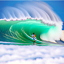
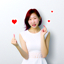
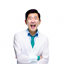
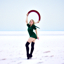
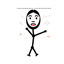
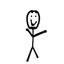

In [ ]:
drawn_im = Image.open('output/1_7_1_2_1.png').resize((64, 64))
drawn_im = TF.to_tensor(drawn_im)
drawn_im = 2 * drawn_im - 1
drawn_im = drawn_im[None]

media.show_image(drawn_im[0].permute(1,2,0) / 2. + 0.5)

prompt_embeds = prompt_embeds_dict["a high quality photo"]

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
  # Add noise
  t = strided_timesteps[i_start]
  im_noisy = forward(drawn_im, t).half().to(device)

  # Denoise
  clean = iterative_denoise_cfg(im_noisy,
                                i_start=i_start,
                                prompt_embeds=prompt_embeds,
                                uncond_prompt_embeds=uncond_prompt_embeds,
                                timesteps=strided_timesteps,
                                display=False)

  # Add to dict to display later
  imgs_dict[i_start] = clean[0].transpose(1,2,0) / 2. + 0.5

media.show_images(imgs_dict)

""

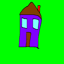

100%|██████████| 6/6 [01:29<00:00, 14.85s/it]


1,3,5,7,10,20

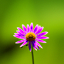
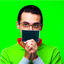
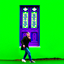
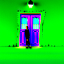
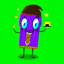
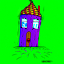

In [ ]:
drawn_im = Image.open('output/1_7_1_3_1.png').resize((64, 64))
drawn_im = TF.to_tensor(drawn_im)
drawn_im = 2 * drawn_im - 1
drawn_im = drawn_im[None]

media.show_image(drawn_im[0].permute(1,2,0) / 2. + 0.5)

prompt_embeds = prompt_embeds_dict["a high quality photo"]

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
  # Add noise
  t = strided_timesteps[i_start]
  im_noisy = forward(drawn_im, t).half().to(device)

  # Denoise
  clean = iterative_denoise_cfg(im_noisy,
                                i_start=i_start,
                                prompt_embeds=prompt_embeds,
                                uncond_prompt_embeds=uncond_prompt_embeds,
                                timesteps=strided_timesteps,
                                display=False)

  # Add to dict to display later
  imgs_dict[i_start] = clean[0].transpose(1,2,0) / 2. + 0.5

media.show_images(imgs_dict)

# 1.7.2 Inpainting

Image,Mask,To Replace

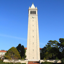
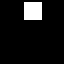
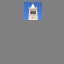

1_7_2_mask_1

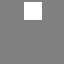

1_7_2_replace_1

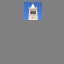

In [ ]:
# EDIT ME!
# Make mask
mask = torch.zeros_like(test_im)
mask[:, :, 2:20, 24:42] = 1.0
mask = mask.to(device)

# Visualize mask
media.show_images({
    'Image': test_im[0].permute(1,2,0) / 2. + 0.5,
    'Mask': mask.cpu()[0].permute(1,2,0),
    'To Replace': (test_im * mask.cpu())[0].permute(1,2,0) / 2. + 0.5,
})
title = '1_7_2_mask_1'
media.show_image(np.transpose(mask.cpu()[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_2_replace_1'
media.show_image(np.transpose((test_im * mask.cpu())[0], (1, 2, 0)) / 2. + 0.5, title=title)

1_7_2_original_1

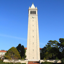

1_7_2_inpainting_1

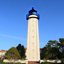

In [ ]:
# The condition prompt embedding
prompt_embeds = prompt_embeds_dict['a high quality photo']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']

def inpaint(original_image, mask, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=False):
  original_image = original_image.to(device).half()
  image = torch.randn_like(original_image).to(device).half()
  mask = mask.to(device).half()
  with torch.no_grad():
    loop_number = 0
    i_start = 0
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # Get alphas, betas

      alpha_cumprod = alphas_cumprod[t]
      alpha_cumprod_prev = alphas_cumprod[prev_t]
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # Get cond noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)

      # Do classifier free guidance

      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)

      # Eq (6) and (7) of DDPM

      clean_est = (image - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
      pred_prev_image = (alpha_cumprod_prev**0.5 * beta * clean_est)/(1 - alpha_cumprod) + (alpha ** 0.5 * (1 - alpha_cumprod_prev) * image)/(1 - alpha_cumprod) 
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)

      pred_prev_image = pred_prev_image * mask + (1 - mask) * forward(original_image, prev_t)

      # pred_prev_image = pred_prev_image * mask

      loop_number += 1
      if loop_number % 5 == 1 and display:
        title = '1_5_Noisy_Campanile_t_' + str(t)
        media.show_image(pred_prev_image.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

generated = {}

title = '1_7_2_original_1'
media.show_image(np.transpose(test_im[0], (1, 2, 0)) / 2. + 0.5, title=title)
clean = inpaint(test_im,
                      mask=mask,
                      prompt_embeds=prompt_embeds,
                      uncond_prompt_embeds=uncond_prompt_embeds,
                      timesteps=strided_timesteps)
title = '1_7_2_inpainting_1'
media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
generated[i] = clean

Processed image


""

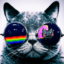

Image,Mask,To Replace

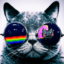
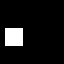
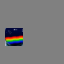

1_7_2_mask_2

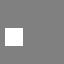

1_7_2_replace_2

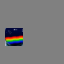

In [ ]:
url = "https://pbs.twimg.com/profile_images/969338395070730246/Y91ernB4_400x400.jpg"

# Download image from URL and process
response = requests.get(url)
web_im = Image.open(BytesIO(response.content))
web_im = process_pil_im(web_im)
# Make mask 2
mask = torch.zeros_like(web_im)
mask[:, :, 28:46, 5:23] = 1.0
mask = mask.to(device)

# Visualize mask
media.show_images({
    'Image': web_im[0].permute(1,2,0) / 2. + 0.5,
    'Mask': mask.cpu()[0].permute(1,2,0),
    'To Replace': (web_im * mask.cpu())[0].permute(1,2,0) / 2. + 0.5,
})
title = '1_7_2_mask_2'
media.show_image(np.transpose(mask.cpu()[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_2_replace_2'
media.show_image(np.transpose((web_im * mask.cpu())[0], (1, 2, 0)) / 2. + 0.5, title=title)

1_7_2_original_2

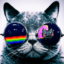

1_7_2_inpainting_2

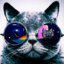

In [ ]:
title = '1_7_2_original_2'
media.show_image(np.transpose(web_im[0], (1, 2, 0)) / 2. + 0.5, title=title)
clean = inpaint(web_im,
                      mask=mask,
                      prompt_embeds=prompt_embeds,
                      uncond_prompt_embeds=uncond_prompt_embeds,
                      timesteps=strided_timesteps)
title = '1_7_2_inpainting_2'
media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
generated[i] = clean

Image,Mask,To Replace

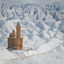
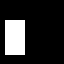
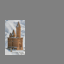

1_7_2_mask_3

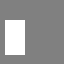

1_7_2_replace_3

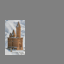

In [ ]:
web_im = Image.open('data/snowchurch.jpg').resize((64, 64))
web_im = TF.to_tensor(web_im)
web_im = 2 * web_im - 1
web_im = web_im[None]
# Make mask 2
mask = torch.zeros_like(web_im)
mask[:, :, 20:55, 5:25] = 1.0
mask = mask.to(device)

# Visualize mask
media.show_images({
    'Image': web_im[0].permute(1,2,0) / 2. + 0.5,
    'Mask': mask.cpu()[0].permute(1,2,0),
    'To Replace': (web_im * mask.cpu())[0].permute(1,2,0) / 2. + 0.5,
})
title = '1_7_2_mask_3'
media.show_image(np.transpose(mask.cpu()[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_2_replace_3'
media.show_image(np.transpose((web_im * mask.cpu())[0], (1, 2, 0)) / 2. + 0.5, title=title)

1_7_2_original_3

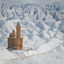

1_7_2_inpainting_3

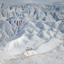

In [ ]:
title = '1_7_2_original_3'
media.show_image(np.transpose(web_im[0], (1, 2, 0)) / 2. + 0.5, title=title)
clean = inpaint(web_im,
                      mask=mask,
                      prompt_embeds=prompt_embeds,
                      uncond_prompt_embeds=uncond_prompt_embeds,
                      timesteps=strided_timesteps)
title = '1_7_2_inpainting_3'
media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
generated[i] = clean

# 1.7.3 Text-Conditioned Image-to-image Translation

1_7_3_img1_istart_1

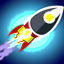

1_7_3_img1_istart_3

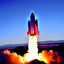

1_7_3_img1_istart_5

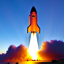

1_7_3_img1_istart_7

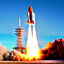

1_7_3_img1_istart_10

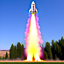

1_7_3_img1_istart_20

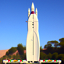

1_7_3_img2_istart_original

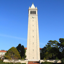

In [ ]:
prompt_embeds = prompt_embeds_dict["a rocket ship"]

imgs_dict = {}
# Image 1
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=7)
    title = '1_7_3_img1_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_3_img2_istart_original'
media.show_image(test_im[0].permute(1,2,0) / 2. + 0.5, title=title)

1_7_3_img2_istart_1

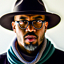

1_7_3_img2_istart_3

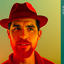

1_7_3_img2_istart_5

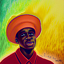

1_7_3_img2_istart_7

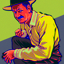

1_7_3_img2_istart_10

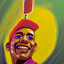

1_7_3_img2_istart_20

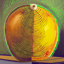

1_7_3_img2_istart_original

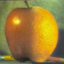

In [ ]:
prompt_embeds = prompt_embeds_dict["a man wearing a hat"]
# Image 2
test_im2 = Image.open('data/oranapple.png').resize((64, 64))
test_im2 = TF.to_tensor(test_im2)
test_im2 = 2 * test_im2 - 1
test_im2 = test_im2[None]
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im2, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=7)
    title = '1_7_3_img2_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_3_img2_istart_original'
media.show_image(test_im2[0].permute(1,2,0) / 2. + 0.5, title=title)

1_7_3_img3_istart_1

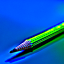

1_7_3_img3_istart_3

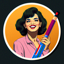

1_7_3_img3_istart_5

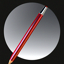

1_7_3_img3_istart_7

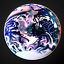

1_7_3_img3_istart_10

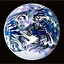

1_7_3_img3_istart_20

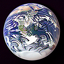

1_7_3_img3_istart_original

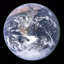

In [ ]:
# Image 3
prompt_embeds = prompt_embeds_dict["a pencil"]

test_im3 = Image.open('data/earth.jpg').resize((64, 64))
test_im3 = TF.to_tensor(test_im3)
test_im3 = 2 * test_im3 - 1
test_im3 = test_im3[None]
for i in [1, 3, 5, 7, 10, 20]:
    t = strided_timesteps[i]
    im_noisy = forward(test_im3, t).half().to(torch.device(device))
    clean = iterative_denoise_cfg(im_noisy,
                          i_start=i,
                          prompt_embeds=prompt_embeds,
                          uncond_prompt_embeds=uncond_prompt_embeds,
                          timesteps=strided_timesteps,
                          scale=7)
    title = '1_7_3_img3_istart_' + str(i)
    media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
title = '1_7_3_img3_istart_original'
media.show_image(test_im3[0].permute(1,2,0) / 2. + 0.5, title=title)

## 1.8 Visual Anagrams

""

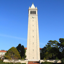

torch.Size([1, 3, 64, 64])


""

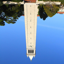

In [ ]:
media.show_image(np.transpose(test_im[0], (1, 2, 0)) / 2. + 0.5)
print(test_im.shape)
rotated_image = torch.flip(test_im, dims=[2, 3])
media.show_image(np.transpose(rotated_image[0], (1, 2, 0)) / 2. + 0.5)


1_8_no0

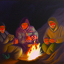

1_8_no1

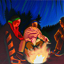

1_8_no2

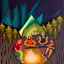

In [ ]:
# The condition prompt embedding
prompt_embeds = prompt_embeds_dict['an oil painting of people around a campfire']
prompt_embeds2 = prompt_embeds_dict['an oil painting of an old man']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']

def make_flip_illusion(original_image, i_start, prompt_embeds, prompt_embeds2, uncond_prompt_embeds, timesteps, scale=7, display=False):
  image = torch.randn_like(original_image).to(device).half()
  with torch.no_grad():
    loop_number = 0
    i_start = 0
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # Get alphas, betas

      alpha_cumprod = alphas_cumprod[t]
      alpha_cumprod_prev = alphas_cumprod[prev_t]
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # Get cond noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)

      # We do the same for our rotated image
      rotated_image = torch.flip(image, dims=[2, 3])
      model_output2 = stage_1.unet(
          rotated_image,
          t,
          encoder_hidden_states=prompt_embeds2,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output2 = stage_1.unet(
          rotated_image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est2, predicted_variance2 = torch.split(model_output2, image.shape[1], dim=1)
      uncond_noise_est2, _ = torch.split(uncond_model_output2, image.shape[1], dim=1)

      noise_est2 = torch.flip(noise_est2, dims=[2, 3])
      predicted_variance2 = torch.flip(predicted_variance2, dims=[2, 3])
      uncond_noise_est2 = torch.flip(uncond_noise_est2, dims=[2, 3])

      # Do classifier free guidance

      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)
      noise_est2 = uncond_noise_est2 + scale * (noise_est2 - uncond_noise_est2)

      noise_average = (noise_est + noise_est2) / 2

      # Eq (6) and (7) of DDPM

      clean_est = (image - (1 - alpha_cumprod)**0.5 * noise_average) / (alpha_cumprod**0.5)
      pred_prev_image = (alpha_cumprod_prev**0.5 * beta * clean_est)/(1 - alpha_cumprod) + (alpha ** 0.5 * (1 - alpha_cumprod_prev) * image)/(1 - alpha_cumprod) 
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)

      loop_number += 1
      if loop_number % 5 == 1 and display:
        title = 'temp' + str(t)
        media.show_image(pred_prev_image.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

generated = {}
for i in range(3):
  clean = make_flip_illusion(test_im,
                        i_start=0,
                        prompt_embeds=prompt_embeds,
                        prompt_embeds2=prompt_embeds2,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_8_1_no' + str(i)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

1_8_2_no1

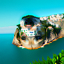

1_8_2_no2

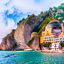

1_8_2_no3

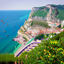

In [ ]:
prompt_embeds = prompt_embeds_dict['a photo of the amalfi cost']
prompt_embeds2 = prompt_embeds_dict['a photo of a dog']
for i in range(3):
  clean = make_flip_illusion(test_im,
                        i_start=0,
                        prompt_embeds=prompt_embeds,
                        prompt_embeds2=prompt_embeds2,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_8_2_no' + str(i+1)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

In [ ]:
# test_im = Image.open('output/1_8_3_no2.png')
# prompt_embeds = prompt_embeds_dict['an oil painting of a snowy mountain village']
# test_im = TF.to_tensor(test_im)
# test_im = 2 * test_im - 1
# test_im = test_im[None]

# # Show test image
# print('Test image:')
# media.show_image(test_im[0].permute(1,2,0) / 2. + 0.5)
# newnew_image = upsample(test_im, prompt_embeds)
# media.show_image(newnew_image[0].permute(1,2,0) / 2. + 0.5)
# media.show_image(newnew_image[0].permute(1,2,0) / 2. + 0.5, title='1_8_3_no2_upsample')


1_8_3_no1

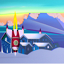

1_8_3_no2

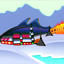

1_8_3_no3

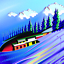

In [ ]:
prompt_embeds = prompt_embeds_dict['an oil painting of a snowy mountain village']
prompt_embeds2 = prompt_embeds_dict['a rocket ship']
for i in range(3):
  clean = make_flip_illusion(test_im,
                        i_start=0,
                        prompt_embeds=prompt_embeds,
                        prompt_embeds2=prompt_embeds2,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_8_3_no' + str(i+1)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

## 1.10 Hybrid Images

1_9_1_no1

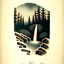

1_9_1_no2

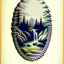

1_9_1_no3

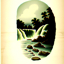

In [21]:
# The condition prompt embedding
prompt_embeds_lowpass = prompt_embeds_dict['a lithograph of a skull']
prompt_embeds_highpass = prompt_embeds_dict['a lithograph of waterfalls']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']

def make_hybrids(original_image, i_start, prompt_embeds_lowpass, prompt_embeds_highpass, uncond_prompt_embeds, timesteps, scale=7, display=False):
  image = torch.randn_like(original_image).to(device).half()
  with torch.no_grad():
    loop_number = 0
    i_start = 0
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # Get alphas, betas

      alpha_cumprod = alphas_cumprod[t]
      alpha_cumprod_prev = alphas_cumprod[prev_t]
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # Get cond noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds_lowpass,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)

      # We do the same for our rotated image
      model_output2 = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds_highpass,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output2 = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est2, predicted_variance2 = torch.split(model_output2, image.shape[1], dim=1)
      uncond_noise_est2, _ = torch.split(uncond_model_output2, image.shape[1], dim=1)

      # Do classifier free guidance

      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)
      noise_est2 = uncond_noise_est2 + scale * (noise_est2 - uncond_noise_est2)

      low_freq_1 = TF.gaussian_blur(noise_est, 33, 2)
      low_freq_2 = TF.gaussian_blur(noise_est2, 33, 2)

      high_frequency_2 = noise_est2 - low_freq_2
      noise_average = low_freq_1 + high_frequency_2

      # Eq (6) and (7) of DDPM

      clean_est = (image - (1 - alpha_cumprod)**0.5 * noise_average) / (alpha_cumprod**0.5)
      pred_prev_image = (alpha_cumprod_prev**0.5 * beta * clean_est)/(1 - alpha_cumprod) + (alpha ** 0.5 * (1 - alpha_cumprod_prev) * image)/(1 - alpha_cumprod) 
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)

      loop_number += 1
      if loop_number % 5 == 1 and display:
        title = 'temp' + str(t)
        media.show_image(pred_prev_image.cpu().detach()[0].permute(1,2,0) / 2. + 0.5, title=title)

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

generated = {}
for i in range(3):
  clean = make_hybrids(test_im,
                        i_start=0,
                        prompt_embeds_lowpass=prompt_embeds_lowpass,
                        prompt_embeds_highpass=prompt_embeds_highpass,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_9_1_no' + str(i + 1)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

1_9_2_no1

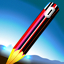

1_9_2_no2

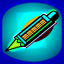

1_9_2_no3

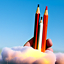

In [ ]:
prompt_embeds_lowpass = prompt_embeds_dict['a rocket ship']
prompt_embeds_highpass = prompt_embeds_dict['a pencil']
for i in range(3):
  clean = make_hybrids(test_im,
                        i_start=0,
                        prompt_embeds_lowpass=prompt_embeds_lowpass,
                        prompt_embeds_highpass=prompt_embeds_highpass,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_9_2_no' + str(i+1)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

1_9_3_no1

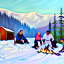

1_9_3_no2

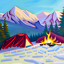

1_9_3_no3

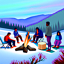

In [ ]:
prompt_embeds_lowpass = prompt_embeds_dict['an oil painting of a snowy mountain village']
prompt_embeds_highpass = prompt_embeds_dict['an oil painting of people around a campfire']
for i in range(3):
  clean = make_hybrids(test_im,
                        i_start=0,
                        prompt_embeds_lowpass=prompt_embeds_lowpass,
                        prompt_embeds_highpass=prompt_embeds_highpass,
                        uncond_prompt_embeds=uncond_prompt_embeds,
                        timesteps=strided_timesteps,
                        display=False)
  title = '1_9_3_no' + str(i+1)
  media.show_image(np.transpose(clean[0], (1, 2, 0)) / 2. + 0.5, title=title)
  generated[i] = clean

# Using Your Own Text Prompts

In [ ]:
# @title Loading T5 text encoder

# Load the T5 text encoder (this may take a while)
text_encoder = T5EncoderModel.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    subfolder="text_encoder",
    load_in_8bit=True,
    variant="8bit",
)
text_pipe = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=text_encoder,  # pass the previously instantiated text encoder
    unet=None
)

In [ ]:
# @title Making prompt embeds dict

# Prompts to put into dictionary
def get_prompt_embeds_dict():
  prompts = [
    'an oil painting of a snowy mountain village',
    'a photo of the amalfi cost',
    'a photo of a man',
    'a photo of a hipster barista',
    'a photo of a dog',
    'an oil painting of people around a campfire',
    'an oil painting of an old man',
    'a lithograph of waterfalls',
    'a lithograph of a skull',
    'a man wearing a hat',
    'a high quality photo',
    "a rocket ship",
    "a pencil"
    '',   # For CFG
  ]

  # Get prompt embeddings using the T5 model
  # each embedding is of shape [1, 77, 4096]
  # 77 comes from the max sequence length that deepfloyd will take
  # and 4096 comes from the embedding dimension of the text encoder
  prompt_embeds = [text_pipe.encode_prompt(prompt) for prompt in prompts]
  prompt_embeds, negative_prompt_embeds = zip(*prompt_embeds)
  prompt_embeds_dict = dict(zip(prompts, prompt_embeds))

  return prompt_embeds_dict

In [ ]:
prompt_embeds_dict = get_prompt_embeds_dict()

# @title Exporting prompt embeds dict

# Save prompt embeds to colab disk
torch.save(prompt_embeds_dict, 'prompt_embeds_dict.pth')

# Download prompt embeds
from google.colab import files
files.download('prompt_embeds_dict.pth')

# [Optional] Upsampling Images

In [ ]:
def upsample(image64, prompt_embeds):
  """
  Args:
    image64 : torch tensor of size (1, 3, 64, 64) representing the image
    prompt_embeds : torch tensor of size (1, 77, 4096), prompt embedding

  Returns:
    image256 : torch tensor of size (1, 3, 256, 256), upsampled image
  """

  image256 = stage_2(
      image=image64,
      num_inference_steps=30,
      prompt_embeds=prompt_embeds,
      negative_prompt_embeds=prompt_embeds_dict[''],
      output_type="pt",
  ).images.cpu()

  return image256

hybrid_256 = upsample(torch.tensor(clean),
                      prompt_embeds[:1])
media.show_images(
    {
        'hybrid': hybrid_256[0].permute(1,2,0) / 2. + 0.5,
    }
)

  0%|          | 0/30 [00:08<?, ?it/s]
